In [70]:
# Library import

import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
sns.set_style('darkgrid')

In [4]:
# Read csv with charts by region data
region = pd.read_csv(r'..\data\eu_charts_with_tracks_data.csv')
region.info()

<class 'pandas.DataFrame'>
RangeIndex: 5468937 entries, 0 to 5468936
Data columns (total 25 columns):
 #   Column            Dtype  
---  ------            -----  
 0   title             str    
 1   rank              int64  
 2   date              str    
 3   region            str    
 4   chart             str    
 5   streams           float64
 6   track_id          str    
 7   popularity        int64  
 8   duration_ms       int64  
 9   explicit          int64  
 10  artists           str    
 11  id_artists        str    
 12  release_date      str    
 13  danceability      float64
 14  energy            float64
 15  key               int64  
 16  loudness          float64
 17  mode              int64  
 18  speechiness       float64
 19  acousticness      float64
 20  instrumentalness  float64
 21  liveness          float64
 22  valence           float64
 23  tempo             float64
 24  time_signature    int64  
dtypes: float64(10), int64(7), str(8)
memory usage: 1.0 GB


In [ ]:
# calculate the average BPM by country
bpm = round(region.groupby('region', as_index = False)['tempo'].mean(),3)

In [ ]:
# Import latitude informations (average latitude for each country according to wikipedia)
latitude = pd.read_csv(r'..\data\wiki\latitude.csv')
latitude.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   index             23 non-null     int64  
 1   country           23 non-null     str    
 2   avg_latitude_deg  23 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 684.0 bytes


In [ ]:
# Merge bpm df with latitude containing the average latitude for each country
bpm_merged = bpm.merge(latitude, left_on='region', right_on='country').drop(columns = ['index', 'country'])
bpm_merged

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   region            23 non-null     str    
 1   tempo             23 non-null     float64
 2   avg_latitude_deg  23 non-null     float64
dtypes: float64(2), str(1)
memory usage: 684.0 bytes


In [68]:
# Cathegorize the data based on north/south position with respect to the average latitude of the dataset
bpm_merged['north_south'] = np.where(bpm_merged.avg_latitude_deg >= bpm_merged.avg_latitude_deg.mean(), 'north', 'south')
bpm_merged

,region,tempo,avg_latitude_deg,cluster,north_south
0,Austria,119.475,47.33,0,south
1,Belgium,118.141,50.83,0,north
2,Bulgaria,125.006,43.00,1,south
3,Czech Republic,119.580,49.75,0,south
4,Denmark,117.641,56.00,2,north
5,Estonia,119.811,58.40,2,north
6,Finland,120.074,64.00,2,north
7,France,120.960,46.00,0,south
8,Germany,119.407,51.15,0,north
9,Greece,120.535,39.00,1,south


In [69]:
# 1. Import stats
from scipy import stats

# 2. Group Separation
north_bpm = bpm_merged[bpm_merged['north_south'] == 'north']['tempo']
south_bpm = bpm_merged[bpm_merged['north_south'] == 'south']['tempo']

# 3. Performing the T-Test
t_stat, p_val = stats.ttest_ind(north_bpm, south_bpm)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.3f}")

if p_val < 0.05:
    print("✅ The difference is statistically significant!")
else:
    print("❌ There is no evidence of a significant difference.")

T-statistic: -2.172
P-value: 0.041
✅ The difference is statistically significant!


<Axes: xlabel='tempo', ylabel='avg_latitude_deg'>

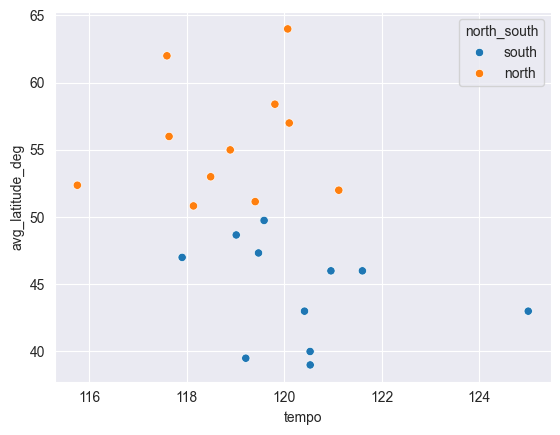

In [71]:
# Visual plot of the data
sns.scatterplot(data = bpm_merged, x = 'tempo', y = 'avg_latitude_deg', hue = 'north_south')

### ⚠️ Attempt of clustering, not definitive!

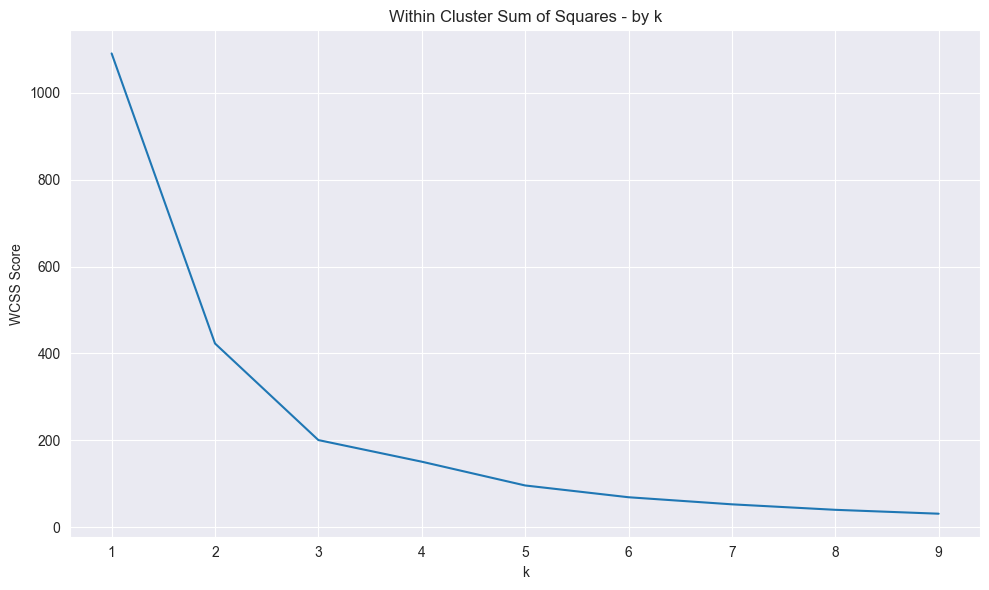

In [72]:
from sklearn.cluster import KMeans


k_values = list(range(1,10))
wcss_list = []

for k in k_values:
	kmeans = KMeans(n_clusters = k, random_state=42)
	kmeans.fit(bpm_merged[['tempo', 'avg_latitude_deg']])
	wcss_list.append(kmeans.inertia_)

plt.pyplot.figure(figsize=(10, 6))
plt.pyplot.plot(k_values, wcss_list)
plt.pyplot.title("Within Cluster Sum of Squares - by k")
plt.pyplot.xlabel("k")
plt.pyplot.ylabel("WCSS Score")
plt.pyplot.tight_layout()
plt.pyplot.show()

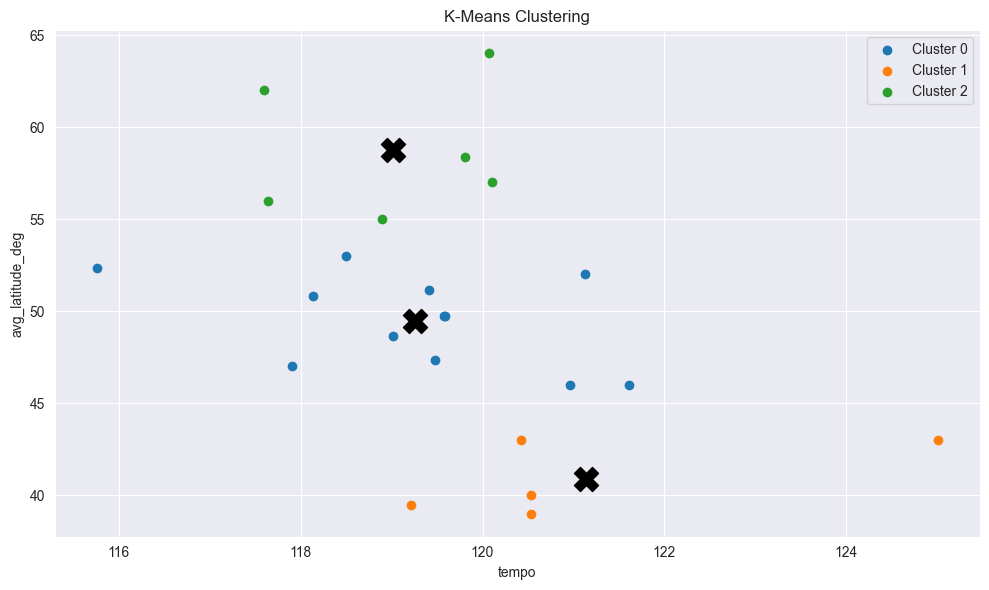

In [73]:
# Instantiate and fit the KMeans model
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(bpm_merged[['tempo', 'avg_latitude_deg']])

# Add the cluster labels to the DataFrame
bpm_merged["cluster"] = kmeans.labels_

# Plot the clusters and centroids
centroids = kmeans.cluster_centers_
clusters = bpm_merged.groupby("cluster")

plt.pyplot.figure(figsize=(10, 6))
for cluster, data in clusters:
    plt.pyplot.scatter(data["tempo"], data["avg_latitude_deg"], marker="o", label=f'Cluster {cluster}')
    plt.pyplot.scatter(centroids[cluster, 0], centroids[cluster, 1], marker="X", color="black", s=300)

plt.pyplot.xlabel("tempo")
plt.pyplot.ylabel("avg_latitude_deg")
plt.pyplot.title("K-Means Clustering")
plt.pyplot.legend()
plt.pyplot.tight_layout()
plt.pyplot.show()